## Predict Product Prices

### Week 7 Day 2

Selecting our model and evaluating the base model against the task.

Keep in mind: our base model has 8 billion params, quantized down to 4 bits
Compared with GPT-4o at TRILLIONS of params!

# IMPORTANT please read me!!

When you run the pip installs below, you may get an error from pip complaining about an incompatible version of fsspec.

You should ignore that error! The version of fsspec is the right version, needed by HuggingFace.

If you ask ChatGPT, it will encourage you to pip install a more recent version of fsspec. But that would be problematic; HuggingFace will fail to load the dataset later with an obscure error about file systems.

So please run the pip installs as they appear below, and look the other way if you get an error!


In [1]:
# pip installs - ignore the error message!

#!pip install -q --upgrade torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
#!pip install -q --upgrade requests==2.32.3 bitsandbytes==0.46.0 transformers==4.48.3 accelerate==1.3.0 datasets==3.2.0 peft==0.14.0 trl==0.14.0 matplotlib

In [2]:
# imports

import os
import re
import math
from tqdm import tqdm
#from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:
# Tokenizers

LLAMA_3_1 = "meta-llama/Meta-Llama-3.1-8B"
QWEN_2_5 = "Qwen/Qwen2.5-7B"
GEMMA_2 = "google/gemma-2-9b"
PHI_3 = "microsoft/Phi-3-medium-4k-instruct"

# Constants

BASE_MODEL = LLAMA_3_1
HF_USER = "ed-donner"
HF_USER = "sergio-sanz-rodriguez"
DATASET_NAME = f"{HF_USER}/pricer-data"
MAX_SEQUENCE_LENGTH = 182
QUANT_4_BIT = False

# Used for writing to output in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

%matplotlib inline

### Log in to HuggingFace

If you don't already have a HuggingFace account, visit https://huggingface.co to sign up and create a token.

Then select the Secrets for this Notebook by clicking on the key icon in the left, and add a new secret called `HF_TOKEN` with the value as your token.

In [4]:
# Log in to HuggingFace

from dotenv import load_dotenv
load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
#hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
def investigate_tokenizer(model_name):
  print("Investigating tokenizer for", model_name)
  tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
  for number in [0, 1, 10, 100, 999, 1000]:
    tokens = tokenizer.encode(str(number), add_special_tokens=False)
    print(f"The tokens for {number}: {tokens}")

In [6]:
# Now we will try this with each model: LLAMA_3_1, QWEN_2_5, GEMMA_2, PHI_3

investigate_tokenizer(LLAMA_3_1)

Investigating tokenizer for meta-llama/Meta-Llama-3.1-8B
The tokens for 0: [15]
The tokens for 1: [16]
The tokens for 10: [605]
The tokens for 100: [1041]
The tokens for 999: [5500]
The tokens for 1000: [1041, 15]


# Load our data

We uploaded it to Hugging Face, so it's easy to retrieve it now

In [7]:
#from huggingface_hub import HfApi

#api = HfApi()
#token = api.login(hf_token)

In [8]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

train-00000-of-00001.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ssre_\.cache\huggingface\hub\datasets--sergio-sanz-rodriguez--pricer-data. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


test-00000-of-00001.parquet:   0%|          | 0.00/915k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [9]:
# Let's avoid curating all our data again! Load in the pickle files:

import pickle
from items import Item
#from testing import Tester
with open(r'../week6_fine_tuning_frontier/train.pkl', 'rb') as file:
    train = pickle.load(file)

with open(r'../week6_fine_tuning_frontier/test.pkl', 'rb') as file:
    test = pickle.load(file)

In [19]:
test[1].title

'APS Premium 6in iBoard Running Boards Compatible with Ford F150 SuperCrew Cab & 17-22 F250 15-23'

# Prepare our Base Llama Model for evaluation

Load our base model with 4 bit quantization and try out 1 example

In [11]:
## pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

Unused kwargs: ['bnb_8bit_compute_dtype']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.


In [12]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token #use end-of-sentence token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.1f} GB")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Memory footprint: 9.1 GB


In [13]:
def extract_price(s):
    if "Price is $" in s:
      contents = s.split("Price is $")[1]
      contents = contents.replace(',','').replace('$','')
      match = re.search(r"[-+]?\d*\.\d+|\d+", contents)
      return float(match.group()) if match else 0
    return 0

In [14]:
extract_price("Price is $999 blah blah so cheap")

999.0

In [15]:
def model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda")
    attention_mask = torch.ones(inputs.shape, device="cuda")
    outputs = base_model.generate(inputs, max_new_tokens=4, attention_mask=attention_mask, num_return_sequences=1)
    response = tokenizer.decode(outputs[0])
    return extract_price(response)

In [ ]:
#model_predict(test[0]['text'])

TypeError: 'Item' object is not subscriptable

# Evaluation!

Trying out our base Llama 3.1 model against the Test dataset

In [22]:
class Tester:

    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        #guess = self.predictor(datapoint["text"])
        #truth = datapoint["price"]
        guess = self.predictor(datapoint.test_prompt())
        truth = datapoint.price
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        #title = datapoint["text"].split("\n\n")[1][:20] + "..."
        title = datapoint.title #.split("\n\n")[1][:20] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

1: Guess: $1,800.00 Truth: $250.56 Error: $1,549.44 SLE: 3.87 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-Post Network Server Relay Rack Rolling with Casters
2: Guess: $1,999.00 Truth: $232.18 Error: $1,766.82 SLE: 4.62 Item: APS Premium 6in iBoard Running Boards Compatible with Ford F150 SuperCrew Cab & 17-22 F250 15-23
3: Guess: $189.00 Truth: $134.87 Error: $54.13 SLE: 0.11 Item: Peerless PTT188792-BL Tub and Shower Trim Kit Tub & Shower, Matte Black
4: Guess: $299.00 Truth: $357.09 Error: $58.09 SLE: 0.03 Item: TransDeco TD600B Stand with Mount, 85" TV, Black
5: Guess: $25.00 Truth: $258.07 Error: $233.07 SLE: 5.29 Item: ACDelco Professional 45K5008 Front Lower Rear Suspension Ball Joint Assembly
6: Guess: $19.95 Truth: $27.95 Error: $8.00 SLE: 0.10 Item: AutoStuff - Camisasca Brushed Finish 2 Hole Wide Bottom License Frame
7: Guess: $60.00 Truth: $170.99 Error: $110.99 SLE: 1.07 Item: HJC Helmets Unisex-Adult Full Face i10 Helmet (White/Black, Medium) (Model: 0810-1430-05)
8: Gue

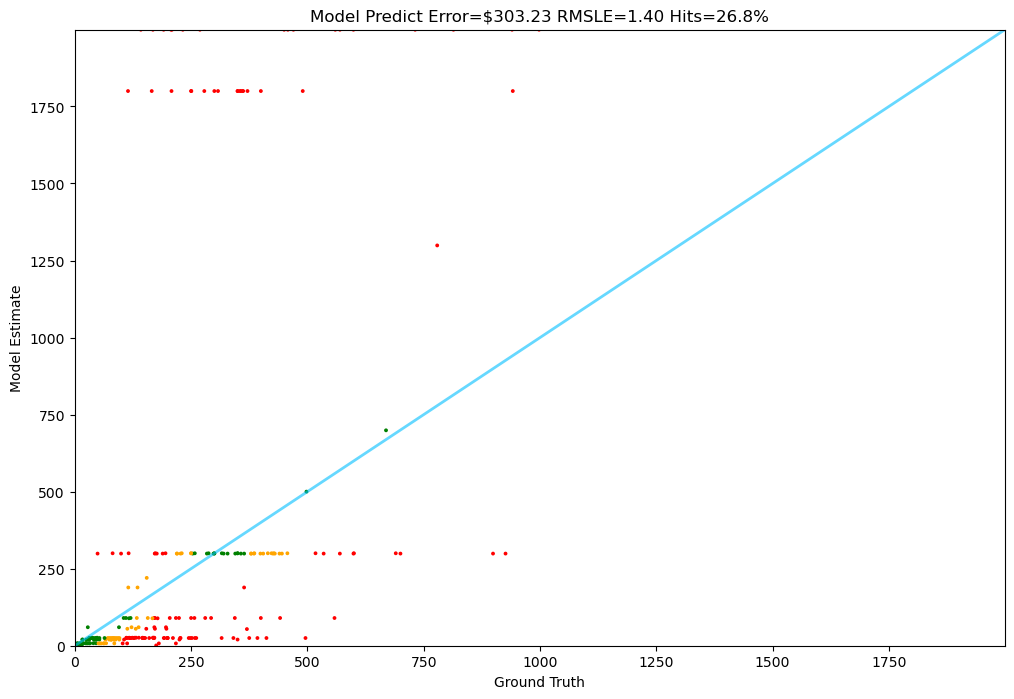

In [23]:
Tester.test(model_predict, test)